# The Machine That Feels: Strain Sensing in Robots and Humanoids

A robot sees the world at a distance, but it *feels* the world only through strain --- and that sense of touch is what lets it stand on two legs, hold an egg without crushing it, and stop the instant it meets a human arm.

Companion notebook to Chapter 63 — The Machine That Feels: Strain Sensing in Robots and Humanoids.

This notebook renders **Figure 63.1(a)**: a cutaway 3D view of a six-axis **force/torque sensor** built on a **Maltese-cross** elastic element, with strain **gages** bonded to the spokes and an applied **wrench** (force $\mathbf{F}$, moment $\mathbf{M}$) acting at the central hub. Panel (b) of the same figure --- a plan-view schematic --- lives in the chapter source as TikZ. The whole point of the picture is the chapter's central claim: *no single gage reads a single wrench component.* Each of the six components paints a distinctive pattern across all eight gages, and the sensor untangles those patterns through its calibration matrix.

## Building the figure

The drawing is deliberately schematic --- its job is to make the *mechanics* legible, not to serve as a manufacturing drawing. We assemble the sensor from simple primitives: a translucent outer **housing ring**, a solid central **hub**, and four **spokes** arranged as a Maltese cross. Two strain gages (blue) sit on the top face of each spoke, giving the eight-gage layout the chapter describes. A red force vector $\mathbf{F}$ and an orange moment arc $\mathbf{M}$ at the hub stand for the applied wrench, and a small coordinate triad fixes the axes used in the chapter's equations.

Every spoke and gage is a rotated box, so we factor that geometry into a single helper, `cuboid_faces`, and reuse it for each part rather than repeating the corner arithmetic.

In [1]:
# Colab: these ship with the default image, but uncomment to install if needed.
# !pip install numpy matplotlib
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

%matplotlib inline
plt.rcParams.update({'font.size': 11})

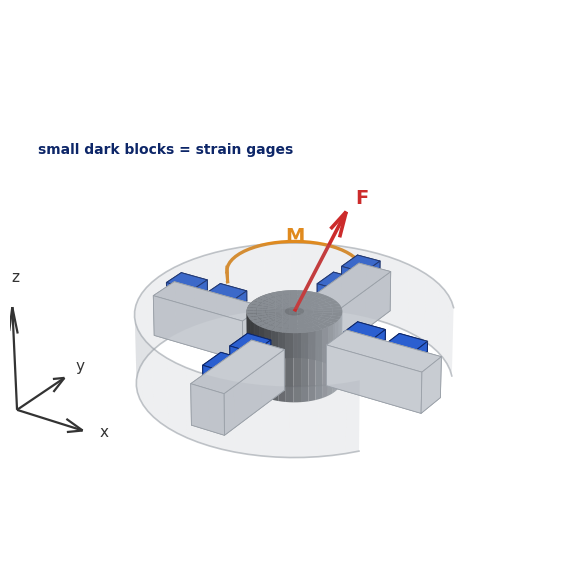

wrote ..\src\media\ch63\fig63_nb1_ft_sensor_3d.png


In [2]:
# ---- Output location -------------------------------------------------------
OUT_DIR = Path("../src/media/ch63")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---- Palette ---------------------------------------------------------------
STEEL, STEEL_DK, HUB = '#c8ccd2', '#9aa0a8', '#b0b6be'   # housing / edges / hub
GAGE, FORCE, TORQUE = '#2b5fd0', '#cc2b2b', '#e08a1e'    # gages / force / moment


def cuboid_faces(center, size, angle=0.0):
    """Return the six quad faces of a box, rotated about z and translated.

    Parameters
    ----------
    center : sequence of 3 floats
        Center of the box, in world coordinates.
    size : sequence of 3 floats
        Full extents (length, width, height) of the box.
    angle : float, optional
        Rotation about the z-axis, in radians.

    Returns
    -------
    list of list of ndarray
        Six faces, each a list of four corner points, ready to hand to
        ``Poly3DCollection``.
    """
    dx, dy, dz = size[0] / 2, size[1] / 2, size[2] / 2
    pts = np.array([
        [-dx, -dy, -dz], [dx, -dy, -dz], [dx, dy, -dz], [-dx, dy, -dz],
        [-dx, -dy, dz], [dx, -dy, dz], [dx, dy, dz], [-dx, dy, dz],
    ])
    c, s = np.cos(angle), np.sin(angle)
    R = np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]])
    pts = pts @ R.T + np.asarray(center)
    idx = [[0, 1, 2, 3], [4, 5, 6, 7], [0, 1, 5, 4],
           [1, 2, 6, 5], [2, 3, 7, 6], [3, 0, 4, 7]]
    return [[pts[i] for i in f] for f in idx]


fig = plt.figure(figsize=(6.6, 5.6))
ax = fig.add_subplot(111, projection='3d')

R_ring, H, R_HUB = 1.0, 0.34, 0.30
th = np.linspace(0, 2 * np.pi, 80)

# Outer housing ring (translucent cylinder wall, cut open in front)
th_wall = np.linspace(np.deg2rad(35), np.deg2rad(325), 60)
Z, T = np.meshgrid([0, H], th_wall)
ax.plot_surface(R_ring * np.cos(T), R_ring * np.sin(T), Z,
                color=STEEL_DK, alpha=0.16, linewidth=0, shade=False)
for z in (0, H):
    ax.plot(R_ring * np.cos(th_wall), R_ring * np.sin(th_wall), z,
            color=STEEL_DK, lw=1.2, alpha=0.6)

# Central hub (solid short cylinder) + top cap
Zc, Tc = np.meshgrid([0, H], th)
ax.plot_surface(R_HUB * np.cos(Tc), R_HUB * np.sin(Tc), Zc,
                color=HUB, alpha=0.95, linewidth=0, shade=True)
rr = np.linspace(0, R_HUB, 6)
Rg, Tg = np.meshgrid(rr, th)
ax.plot_surface(Rg * np.cos(Tg), Rg * np.sin(Tg), np.full_like(Rg, H),
                color=HUB, alpha=0.98, linewidth=0, shade=True)

# Four spokes (Maltese cross) + two strain gages on each top face
rc = (R_HUB + R_ring) / 2
L = (R_ring - R_HUB) - 0.02
for a in [0, 90, 180, 270]:
    ang = np.deg2rad(a)
    center = (rc * np.cos(ang), rc * np.sin(ang), H / 2)
    ax.add_collection3d(Poly3DCollection(
        cuboid_faces(center, (L, 0.24, 0.20), ang),
        facecolor=STEEL, edgecolor=STEEL_DK, linewidths=0.6, alpha=1.0))
    for gr in (rc - 0.14, rc + 0.16):
        gc = (gr * np.cos(ang), gr * np.sin(ang), H / 2 + 0.10 + 0.045)
        ax.add_collection3d(Poly3DCollection(
            cuboid_faces(gc, (0.20, 0.17, 0.05), ang),
            facecolor=GAGE, edgecolor='#0d2668', linewidths=0.7, alpha=1.0))

# Named by appearance, not by colour alone: the softcover edition of the
# book prints this figure in black and white.
ax.text2D(0.05, 0.74, 'small dark blocks = strain gages', transform=ax.transAxes,
          color='#0d2668', fontsize=10, fontweight='bold')

# Applied wrench at the hub top: force vector + torque arc
o = np.array([0, 0, H])
Fvec = np.array([0.30, 0.12, 0.50])
ax.quiver(*o, *Fvec, color=FORCE, lw=2.6, arrow_length_ratio=0.22)
ax.text(o[0] + Fvec[0] + 0.06, o[1] + Fvec[1], o[2] + Fvec[2] + 0.05,
        r'$\mathbf{F}$', color=FORCE, fontsize=14, fontweight='bold')

ta = np.linspace(np.deg2rad(-30), np.deg2rad(215), 40)
r_t, z_t = 0.42, H + 0.20
ax.plot(r_t * np.cos(ta), r_t * np.sin(ta), np.full_like(ta, z_t),
        color=TORQUE, lw=2.4)
tip = ta[-1]
tx, ty = r_t * np.cos(tip), r_t * np.sin(tip)
tang = np.array([-np.sin(tip), np.cos(tip), 0]) * 0.16
ax.quiver(tx, ty, z_t, *tang, color=TORQUE, lw=2.2, arrow_length_ratio=0.9)
ax.text(0.0, 0.0, z_t + 0.14, r'$\mathbf{M}$', color=TORQUE,
        fontsize=14, fontweight='bold', ha='center')

# Coordinate triad
o2 = np.array([-1.25, -1.25, 0.0])
for vec, lab in [((0.5, 0, 0), 'x'), ((0, 0.5, 0), 'y'), ((0, 0, 0.5), 'z')]:
    ax.quiver(*o2, *vec, color='#333', lw=1.6, arrow_length_ratio=0.25)
    ax.text(o2[0] + vec[0] * 1.25, o2[1] + vec[1] * 1.25, o2[2] + vec[2] * 1.25,
            lab, color='#333', fontsize=11)

ax.set_box_aspect((1, 1, 0.62))
ax.view_init(elev=26, azim=-58)
ax.set_xlim(-1.15, 1.15); ax.set_ylim(-1.15, 1.15); ax.set_zlim(0, 1.0)
ax.set_axis_off()
fig.tight_layout(pad=0.2)
fig.savefig(OUT_DIR / 'fig63_nb1_ft_sensor_3d.png', dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()
print('wrote', OUT_DIR / 'fig63_nb1_ft_sensor_3d.png')

## Where to take this next

This notebook draws the sensor; the chapter's physics is waiting to be simulated. Three concrete extensions:

- **Recover a wrench from gage readings.** Build a synthetic $6\times 8$ calibration matrix $\mathbf{A}$, generate noisy gage vectors $\boldsymbol{\varepsilon}$ for known wrenches, and solve $\mathbf{w} = \mathbf{A}(\boldsymbol{\varepsilon} - \boldsymbol{\varepsilon}_0)$ (Eq. 63.1). Add deliberate cross-axis coupling and a nonzero zero-offset $\boldsymbol{\varepsilon}_0$, then measure how much residual error a least-squares fit leaves behind.
- **Animate the zero-moment point.** Sweep the ankle pitch moment $M_y$ across a simulated stride while holding $F_z$ fixed, compute $x_\text{zmp} = -M_y / F_z$ (Eq. 63.3), and shade the support polygon of a 250 mm foot to watch the stability margin shrink toward the toe and grow back.
- **Model a tactile skin.** Lay a grid of taxels over a patch, press a Gaussian "fingertip" load onto it, and reconstruct both the contact location and the normal/shear split from the simulated strain field --- the array-versus-wiring trade-off from the chapter, made concrete in code.